In [ ]:
# Librerias necesarias para el proyecto

# Librerías generales de datos y visualización
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Librerías de Machine Learning (Scikit-Learn)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [ ]:
# Carga y exploración de datos
archivo = 'ai4i2020.csv' 
df = pd.read_csv(archivo)

print("Vista previa de los datos")
display(df.head())

print("--- INFORMACIÓN DEL DATASET ---")
print(f"Fuente: UCI Machine Learning Repository")
print(f"Tamaño (Filas, Columnas): {df.shape}")
print("\nTipos de Variables:")
print(df.dtypes)

print("\n--- DISTRIBUCIÓN DE FALLAS ---")
conteo = df['Machine failure'].value_counts()
print(f"Máquinas OK (0): {conteo[0]}")
print(f"Máquinas con Falla (1): {conteo[1]}")

Vista previa de los datos


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


--- INFORMACIÓN DEL DATASET ---
Fuente: UCI Machine Learning Repository
Tamaño (Filas, Columnas): (10000, 14)

Tipos de Variables:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

--- DISTRIBUCIÓN DE FALLAS ---
Máquinas OK (0): 9661
Máquinas con Falla (1): 339


In [ ]:
# 3. LIMPIEZA Y PREPARACIÓN INICIAL (MODELO BASE)
# Eliminamos identificadores que no aportan valor
df_clean = df.drop(columns=['UDI', 'Product ID'])

# Convertimos variables categóricas en dummy
df_clean = pd.get_dummies(df_clean, columns=['Type'], drop_first=True)

# Separamos X (predictoras) e y (objetivo), evitando "Data Leakage"
X = df_clean.drop(columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df_clean['Machine failure']

# División en Train y Test (Estratificado por el desbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Estandarización de los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Forma de X (Predictoras): (10000, 7)
Forma de y (Objetivo): (10000,)
Distribución de clases en el conjunto de entrenamiento:
Machine failure
0    7729
1     271
Name: count, dtype: int64
Distribución de clases en el conjunto de prueba:
Machine failure
0    1932
1      68
Name: count, dtype: int64



Entrenando el modelo Random Forest Base...

--- REPORTE DE CLASIFICACIÓN (MODELO BASE) ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.94      0.47      0.63        68

    accuracy                           0.98      2000
   macro avg       0.96      0.73      0.81      2000
weighted avg       0.98      0.98      0.98      2000



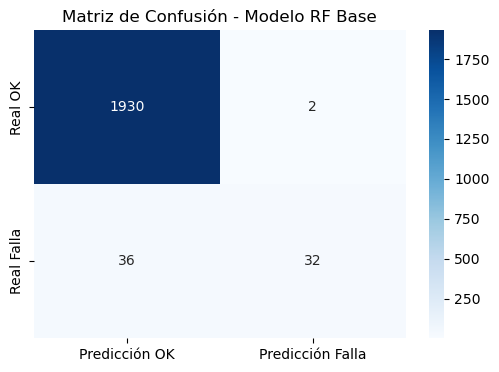

In [29]:
# 4. ENTRENAMIENTO Y EVALUACIÓN: RANDOM FOREST (BASE)
print("\nEntrenando el modelo Random Forest Base...")
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_test_scaled)

print("\n--- REPORTE DE CLASIFICACIÓN (MODELO BASE) ---")
print(classification_report(y_test, y_pred))

# Matriz de Confusión del modelo optimizado
cm_opt = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicción OK', 'Predicción Falla'], 
            yticklabels=['Real OK', 'Real Falla'])
plt.title('Matriz de Confusión - Modelo RF Base')
plt.show()

C:\Users\frank\AppData\Local\Temp\ipykernel_26644\1081767681.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='viridis')


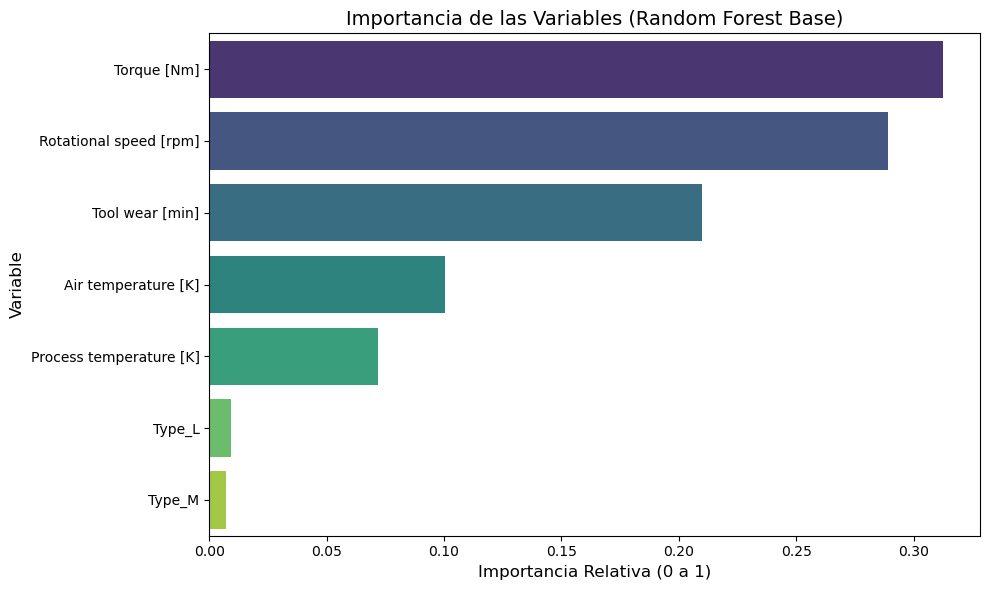


Tabla de Importancia de Variables:


,Variable,Importancia
3,Torque [Nm],0.312612
2,Rotational speed [rpm],0.289263
4,Tool wear [min],0.209803
0,Air temperature [K],0.100226
1,Process temperature [K],0.071705
5,Type_L,0.009284
6,Type_M,0.007107


In [26]:
df_importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='viridis')
plt.title('Importancia de las Variables (Random Forest Base)', fontsize=14)
plt.xlabel('Importancia Relativa (0 a 1)', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.tight_layout()
plt.show()

######### 5. Mostrar la tabla exacta
print("\nTabla de Importancia de Variables:")
display(df_importancias)


Nueva forma de X Optimizada (solo 5 sensores): (10000, 5)
Entrenando el modelo Random Forest Optimizado (Sin 'Type')...

--- REPORTE DE CLASIFICACIÓN (MODELO OPTIMIZADO) ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.56      0.68        68

    accuracy                           0.98      2000
   macro avg       0.93      0.78      0.84      2000
weighted avg       0.98      0.98      0.98      2000



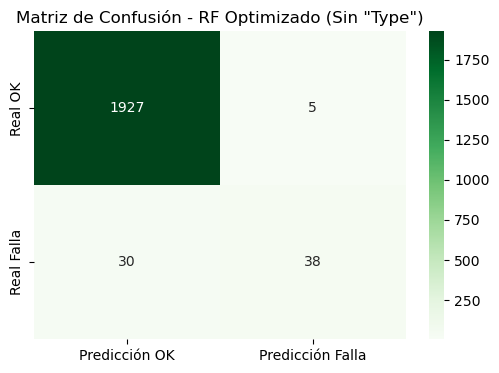

In [27]:
# 6. OPTIMIZACIÓN: ELIMINACIÓN DE VARIABLES Y RE-ENTRENAMIENTO
# ==============================================================================
# Eliminamos las variables 'Type' tras comprobar que su importancia es casi nula
columnas_a_eliminar = [
    'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 
    'Type_L', 'Type_M'
]
X_optimizada = df_clean.drop(columns=columnas_a_eliminar)

print(f"\nNueva forma de X Optimizada (solo {X_optimizada.shape[1]} sensores):", X_optimizada.shape)

# Nueva división y escalado
X_train_opt, X_test_opt, y_train, y_test = train_test_split(
    X_optimizada, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

scaler_opt = StandardScaler()
X_train_opt_scaled = scaler_opt.fit_transform(X_train_opt)
X_test_opt_scaled = scaler_opt.transform(X_test_opt)

# Entrenamiento del modelo optimizado
print("Entrenando el modelo Random Forest Optimizado (Sin 'Type')...")
rf_model_opt = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model_opt.fit(X_train_opt_scaled, y_train)

y_pred_opt = rf_model_opt.predict(X_test_opt_scaled)

print("\n--- REPORTE DE CLASIFICACIÓN (MODELO OPTIMIZADO) ---")
print(classification_report(y_test, y_pred_opt))

# Matriz de Confusión del modelo optimizado
cm_opt = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicción OK', 'Predicción Falla'], 
            yticklabels=['Real OK', 'Real Falla'])
plt.title('Matriz de Confusión - RF Optimizado (Sin "Type")')
plt.show()

Buscando los mejores hiperparámetros... (Esto puede tardar un momento)

¡Búsqueda terminada!
Mejores parámetros encontrados:
 {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}

--- REPORTE DE CLASIFICACIÓN (EL MEJOR MODELO) ---
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.58      0.75      0.65        68

    accuracy                           0.97      2000
   macro avg       0.79      0.87      0.82      2000
weighted avg       0.98      0.97      0.97      2000



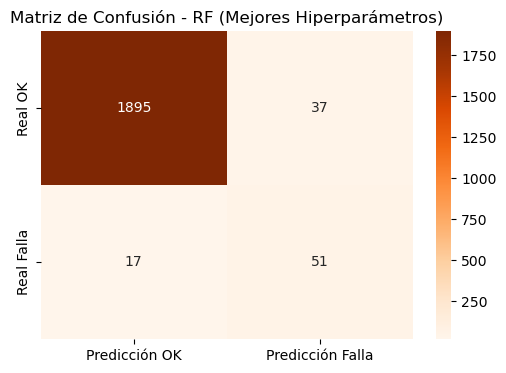

In [ ]:
# 7. Busquedda de Hiperparámetros con GridSearchCV

######### 1. Definir la cuadrícula de parámetros a probar
# Vamos a probar diferentes cantidades de árboles y profundidades
param_grid = {
    'n_estimators': [50, 100, 200],         # Cantidad de árboles en el bosque
    'max_depth': [None, 10, 20],            # Profundidad máxima de cada árbol
    'min_samples_split': [2, 5, 10],        # Mínimo de muestras para dividir un nodo
    'class_weight': ['balanced']            # Siempre mantenemos esto para clases desbalanceadas
}

######### 2. Inicializar el modelo base y el GridSearchCV
# scoring='recall' le dice a la herramienta: "Encuentra la configuración que detecte MÁS fallas"
rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    cv=5,                 # Validación cruzada de 5 pliegues (para asegurar que no sea suerte)
    scoring='recall',     # ¡Nuestra métrica estrella!
    n_jobs=-1             # Usa todos los núcleos de tu procesador para ir más rápido
)

######### 3. Ejecutar la búsqueda con nuestros datos optimizados y escalados
print("Buscando los mejores hiperparámetros... (Esto puede tardar un momento)")
grid_search.fit(X_train_opt_scaled, y_train)

######### 4. Ver los resultados ganadores
print("\n¡Búsqueda terminada!")
print(f"Mejores parámetros encontrados:\n {grid_search.best_params_}")

######### 5. Evaluar el modelo ganador
best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test_opt_scaled)

print("\n--- REPORTE DE CLASIFICACIÓN (EL MEJOR MODELO) ---")
print(classification_report(y_test, y_pred_best))

# Matriz de confusión final
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Predicción OK', 'Predicción Falla'], 
            yticklabels=['Real OK', 'Real Falla'])
plt.title('Matriz de Confusión - RF (Mejores Hiperparámetros)')
plt.show()


ENTRENANDO REGRESIÓN LOGÍSTICA

--- REPORTE DE CLASIFICACIÓN (REGRESIÓN LOGÍSTICA) ---
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.84      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.82      0.88      2000



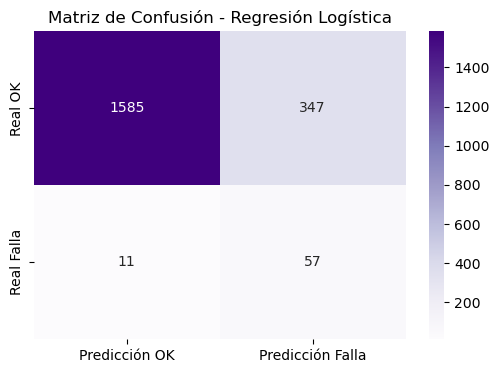


ENTRENANDO SUPPORT VECTOR MACHINE (SVM)

--- REPORTE DE CLASIFICACIÓN (SVM) ---
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1932
           1       0.27      0.93      0.42        68

    accuracy                           0.91      2000
   macro avg       0.63      0.92      0.69      2000
weighted avg       0.97      0.91      0.93      2000



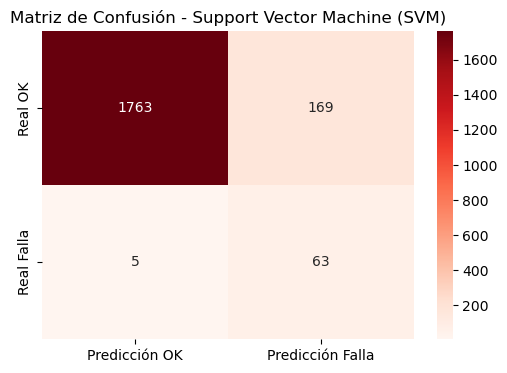

In [ ]:
# 8. COMPARACIÓN CON OTROS ALGORITMOS (REGRESIÓN LOGÍSTICA Y SVM)

# --- 8.1 REGRESIÓN LOGÍSTICA ---
print("\n" + "="*50)
print("ENTRENANDO REGRESIÓN LOGÍSTICA")
print("="*50)

# Usamos max_iter=1000 por si el algoritmo necesita más tiempo para encontrar la línea perfecta
lr_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr_model.fit(X_train_opt_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_opt_scaled)

print("\n--- REPORTE DE CLASIFICACIÓN (REGRESIÓN LOGÍSTICA) ---")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
# Usamos morado (Purples) para distinguir este modelo
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Predicción OK', 'Predicción Falla'], 
            yticklabels=['Real OK', 'Real Falla'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()


# --- 8.2 SUPPORT VECTOR MACHINE (SVM) ---
print("\n" + "="*50)
print("ENTRENANDO SUPPORT VECTOR MACHINE (SVM)")
print("="*50)

# SVM suele tomar un poquito más de tiempo en entrenar que los demás
svm_model = SVC(random_state=42, class_weight='balanced')
svm_model.fit(X_train_opt_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_opt_scaled)

print("\n--- REPORTE DE CLASIFICACIÓN (SVM) ---")
print(classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
# Usamos rojo (Reds) para distinguir este modelo
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicción OK', 'Predicción Falla'], 
            yticklabels=['Real OK', 'Real Falla'])
plt.title('Matriz de Confusión - Support Vector Machine (SVM)')
plt.show()